# Satellite Sky Coverage Exploration

The question we're trying to ask is what combination of satellite orbital altitude and inclination leads to optimal sky coverage over one or more radio observatories, in a fixed period of time.

- Let's explore altitudes between 400-1200 km
- Orbital inclinations are limited between max observatory latitude and 98° (sun synchronous retrograde)
- We set a fixed time period of 180 days for this experiment

In [1]:
import pickle as pkl
from datetime import datetime, timezone
from joblib import Parallel, delayed

from matplotlib.colors import LinearSegmentedColormap as LSC
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import cmasher as cmr
import numpy as np

from skyweaver import Observatory, OrbitSpec, TimeGrid, ground_track, sky_track
from skyweaver.viz import plot_ground_track, plot_sky_track, plot_sky_track_healpix

prd = LSC.from_list("pride", cmr.pride(np.linspace(0.1, 0.8, 256)))
prd.set_under("white")

## Let's choose a set of observatories we're interested in

For now let's stick to the current EoR ones: MWA, HERA, LOFAR

In [2]:
MWA = Observatory.get("MWA")
HERA = Observatory.get("HERA")
LOFAR = Observatory.get("LOFAR")

print(MWA)
print(HERA)
print(LOFAR)

Observatory(name='MWA', latitude_deg=-26.703319, longitude_deg=116.670815, elevation_m=377.83)
Observatory(name='HERA', latitude_deg=-30.7215, longitude_deg=21.4283, elevation_m=1073.0)
Observatory(name='LOFAR', latitude_deg=52.9088, longitude_deg=6.8677, elevation_m=15.0)


## Setup a grid of times

`skyweaver` has two different time options, the first is a coarse grid, used to broadly evaluate satellite orbits around Earth. The second option `pass_cadence_s` defines a finer time cadence for satellite orbit sampling when over an observatory site.

In [3]:
grid = TimeGrid(
    start=datetime(2026, 1, 1, 0, 0, 0, tzinfo=timezone.utc),
    stop=datetime(2026, 7, 1, 0, 0, 0, tzinfo=timezone.utc),
    cadence_s=30,
)

print(grid.summary())

TimeGrid(start=2026-01-01T00:00:00+00:00, stop=2026-07-01T00:00:00+00:00, cadence_s=30.000, n_times=521281)


## Test Orbit

Define test orbital parameters

- altitude: 666 km
- inclination: 66°
- RAAN: 6°
- phase: 42°

In [4]:
orbit = OrbitSpec.circular(
    name="test_666km_i66",
    epoch=datetime(2026, 1, 1, tzinfo=timezone.utc),
    altitude_km=666,
    inclination_deg=66,
    raan_deg=6,
    phase_deg=42,
)

print(orbit.summary())

OrbitSpec(name='test_666km_i66', altitude_km=666.0, inclination_deg=66.000, raan_deg=6.000, mean_anomaly_deg=42.000, eccentricity=0.000000, period_min=98.06)


## Compute ground and sky tracks at observatories

In [5]:
gt = ground_track(orbit, grid)
st_mwa = sky_track(orbit, MWA, grid, pass_cadence_s=1)
st_hera = sky_track(orbit, HERA, grid, pass_cadence_s=1)
st_lofar = sky_track(orbit, LOFAR, grid, pass_cadence_s=1)

use `unique_per_pass=True` to only count a single satellite pass per pixel - this decouples counts from timing cadence

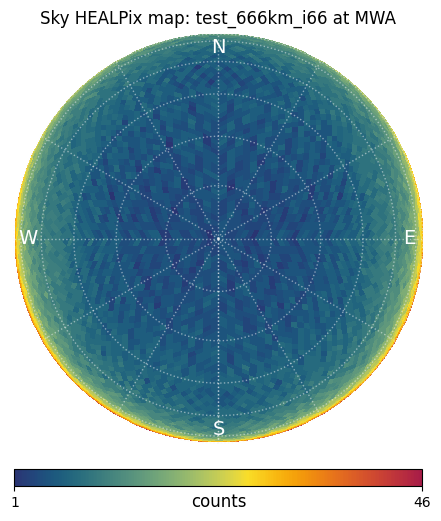

In [6]:
healpix_map = plot_sky_track_healpix(
    st_mwa,
    nside=32,
    unique_per_pass=True,
    cmap=prd,
    bgcolor="white",
)
plt.show()

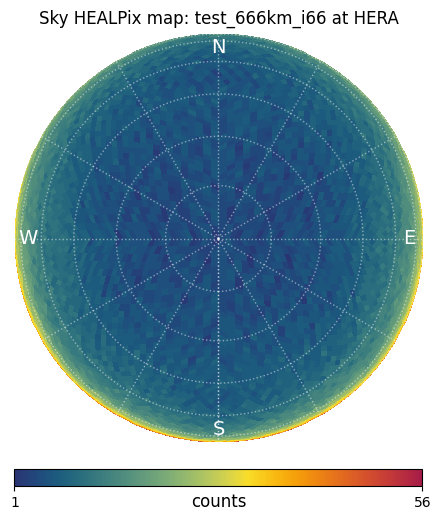

In [7]:
healpix_map = plot_sky_track_healpix(
    st_hera,
    nside=32,
    unique_per_pass=True,
    cmap=prd,
    bgcolor="white",
)
plt.show()

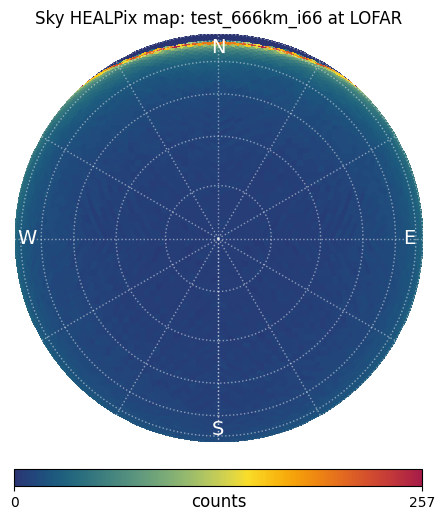

In [8]:
healpix_map = plot_sky_track_healpix(
    st_lofar,
    nside=32,
    unique_per_pass=True,
    cmap=prd,
    bgcolor="white",
)
plt.show()

### Manual Parameter Grid Exploration

Before any Bayesian magic, let's do a brute force grid search and build intuition about the parameter space

In [9]:
def visible_healpix_counts(hp_counts: np.ndarray) -> np.ndarray:
    """Return HEALPix counts for the visible, above-horizon hemisphere."""
    return hp_counts[: hp_counts.size // 2]

def coverage_fraction(hp_counts: np.ndarray) -> float:
    """Fraction of visible-sky HEALPix pixels visited at least once."""
    counts = visible_healpix_counts(hp_counts)
    return np.count_nonzero(counts > 0) / counts.size


def coefficient_of_variation(hp_counts: np.ndarray) -> float:
    """Coefficient of variation over visible-sky pixels, including zeros."""
    counts = visible_healpix_counts(hp_counts)

    mean = np.mean(counts)
    if mean == 0:
        return np.inf

    return np.std(counts) / mean


def coverage_utility(hp_counts: np.ndarray) -> float:
    """Sky coverage utility over the visible hemisphere."""
    f_sky = coverage_fraction(hp_counts)
    cv = coefficient_of_variation(hp_counts)

    if not np.isfinite(cv):
        return 0.0

    return f_sky / (1.0 + cv)

In [10]:
def evaluate_orbit_single_site(
    params: tuple[float, float],
    observatory_name: str,
    start: datetime,
    stop: datetime,
    cadence_s: float,
    nside: int,
    pass_cadence_s: float,
) -> tuple[float, float, float, float, float]:
    """Evaluate one altitude/inclination pair for one observatory."""
    altitude_km, inclination_deg = params

    observatory = Observatory.get(observatory_name)
    grid = TimeGrid(start=start, stop=stop, cadence_s=cadence_s)

    orbit = OrbitSpec.circular(
        name=f"h{altitude_km:.0f}_i{inclination_deg:.1f}",
        epoch=start,
        altitude_km=altitude_km,
        inclination_deg=inclination_deg,
        raan_deg=0.0,
        phase_deg=0.0,
    )

    hp_counts = sky_track(
        orbit,
        observatory,
        grid,
        pass_cadence_s=pass_cadence_s,
    ).to_healpix(nside=nside)

    f_sky = coverage_fraction(hp_counts)
    cv = coefficient_of_variation(hp_counts)
    utility = coverage_utility(hp_counts)

    return altitude_km, inclination_deg, f_sky, cv, utility

In [11]:
altitudes = np.linspace(400, 1200, 32)
inclinations = np.linspace(30, 98, 32)

params = [
    (altitude, inclination)
    for altitude in altitudes
    for inclination in inclinations
]

start = datetime(2026, 1, 1, tzinfo=timezone.utc)
stop = datetime(2026, 7, 1, tzinfo=timezone.utc)

### MWA 

In [12]:
results_mwa = Parallel(n_jobs=12, backend="loky")(
    delayed(evaluate_orbit_single_site)(
        param,
        "MWA",
        start,
        stop,
        30,
        32,
        1,
    )
    for param in params
)

utility_grid_mwa = np.full((len(inclinations), len(altitudes)), np.nan)
fsky_grid_mwa = np.full_like(utility_grid_mwa, np.nan)
cv_grid_mwa = np.full_like(utility_grid_mwa, np.nan)

alt_to_idx = {alt: i for i, alt in enumerate(altitudes)}
inc_to_idx = {inc: i for i, inc in enumerate(inclinations)}

for altitude, inclination, f_sky, cv, utility in results_mwa:
    i = inc_to_idx[inclination]
    j = alt_to_idx[altitude]

    fsky_grid_mwa[i, j] = f_sky
    cv_grid_mwa[i, j] = cv
    utility_grid_mwa[i, j] = utility

data_mwa_grid = {
    "site": "MWA",
    "altitudes": altitudes,
    "inclinations": inclinations,
    "utility": utility_grid_mwa,
    "fsky": fsky_grid_mwa,
    "cv": cv_grid_mwa,
    "metadata": {
        "start": start.isoformat(),
        "stop": stop.isoformat(),
        "cadence_s": 30,
        "nside": 32,
        "pass_cadence_s": 1,
    },
}

with open("data/mwa_grid_nside32.pkl", "wb") as f:
    pkl.dump(data_mwa_grid, f)

/Users/achokshi/Repos/skycov/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


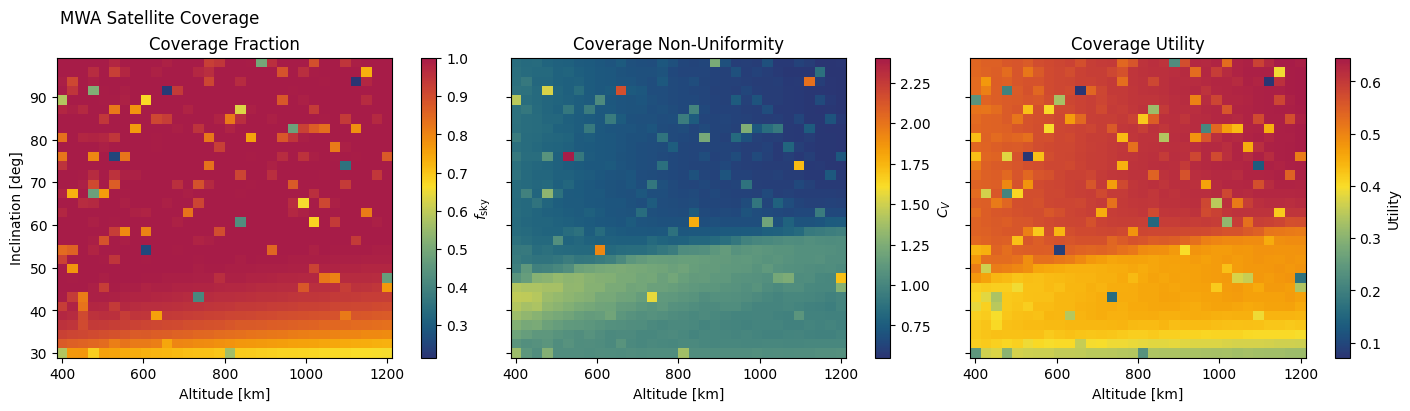

In [25]:
fig, axs = plt.subplots(
    ncols=3,
    figsize=(14, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

im0 = axs[0].pcolormesh(
    altitudes,
    inclinations,
    fsky_grid_mwa,
    shading="auto",
    cmap=prd
)

cbar0 = fig.colorbar(im0, ax=axs[0])
cbar0.set_label(r"$f_\mathrm{sky}$")

axs[0].set_title("Coverage Fraction")
axs[0].set_xlabel("Altitude [km]")
axs[0].set_ylabel("Inclination [deg]")


im1 = axs[1].pcolormesh(
    altitudes,
    inclinations,
    cv_grid_mwa,
    shading="auto",
    cmap=prd
)

cbar1 = fig.colorbar(im1, ax=axs[1])
cbar1.set_label(r"$C_V$")

axs[1].set_title("Coverage Non-Uniformity")
axs[1].set_xlabel("Altitude [km]")


im2 = axs[2].pcolormesh(
    altitudes,
    inclinations,
    utility_grid_mwa,
    shading="auto",
    cmap=prd
)

cbar2 = fig.colorbar(im2, ax=axs[2])
cbar2.set_label("Utility")

axs[2].set_title("Coverage Utility")
axs[2].set_xlabel("Altitude [km]")

fig.suptitle("MWA Satellite Coverage", x=0.11)

plt.show()

### HERA

In [14]:
results_hera = Parallel(n_jobs=12, backend="loky")(
    delayed(evaluate_orbit_single_site)(
        param,
        "HERA",
        start,
        stop,
        30,
        32,
        1,
    )
    for param in params
)

utility_grid_hera = np.full((len(inclinations), len(altitudes)), np.nan)
fsky_grid_hera = np.full_like(utility_grid_hera, np.nan)
cv_grid_hera = np.full_like(utility_grid_hera, np.nan)

alt_to_idx = {alt: i for i, alt in enumerate(altitudes)}
inc_to_idx = {inc: i for i, inc in enumerate(inclinations)}

for altitude, inclination, f_sky, cv, utility in results_hera:
    i = inc_to_idx[inclination]
    j = alt_to_idx[altitude]

    fsky_grid_hera[i, j] = f_sky
    cv_grid_hera[i, j] = cv
    utility_grid_hera[i, j] = utility

data_hera_grid = {
    "site": "HERA",
    "altitudes": altitudes,
    "inclinations": inclinations,
    "utility": utility_grid_hera,
    "fsky": fsky_grid_hera,
    "cv": cv_grid_hera,
    "metadata": {
        "start": start.isoformat(),
        "stop": stop.isoformat(),
        "cadence_s": 30,
        "nside": 32,
        "pass_cadence_s": 1,
    },
}

with open("data/hera_grid_nside32.pkl", "wb") as f:
    pkl.dump(data_hera_grid, f)

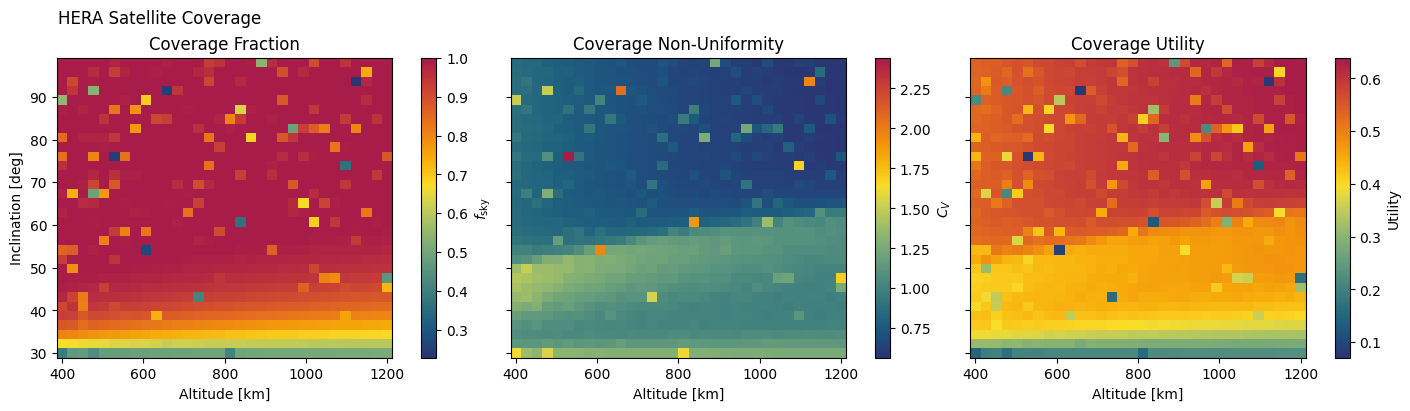

In [26]:
fig, axs = plt.subplots(
    ncols=3,
    figsize=(14, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

im0 = axs[0].pcolormesh(
    altitudes,
    inclinations,
    fsky_grid_hera,
    shading="auto",
    cmap=prd
)

cbar0 = fig.colorbar(im0, ax=axs[0])
cbar0.set_label(r"$f_\mathrm{sky}$")

axs[0].set_title("Coverage Fraction")
axs[0].set_xlabel("Altitude [km]")
axs[0].set_ylabel("Inclination [deg]")


im1 = axs[1].pcolormesh(
    altitudes,
    inclinations,
    cv_grid_hera,
    shading="auto",
    cmap=prd
)

cbar1 = fig.colorbar(im1, ax=axs[1])
cbar1.set_label(r"$C_V$")

axs[1].set_title("Coverage Non-Uniformity")
axs[1].set_xlabel("Altitude [km]")


im2 = axs[2].pcolormesh(
    altitudes,
    inclinations,
    utility_grid_hera,
    shading="auto",
    cmap=prd
)

cbar2 = fig.colorbar(im2, ax=axs[2])
cbar2.set_label("Utility")

axs[2].set_title("Coverage Utility")
axs[2].set_xlabel("Altitude [km]")

fig.suptitle("HERA Satellite Coverage", x=0.11)

plt.show()

### LOFAR

In [16]:
results_lofar = Parallel(n_jobs=12, backend="loky")(
    delayed(evaluate_orbit_single_site)(
        param,
        "LOFAR",
        start,
        stop,
        30,
        32,
        1,
    )
    for param in params
)

utility_grid_lofar = np.full((len(inclinations), len(altitudes)), np.nan)
fsky_grid_lofar = np.full_like(utility_grid_lofar, np.nan)
cv_grid_lofar = np.full_like(utility_grid_lofar, np.nan)

alt_to_idx = {alt: i for i, alt in enumerate(altitudes)}
inc_to_idx = {inc: i for i, inc in enumerate(inclinations)}

for altitude, inclination, f_sky, cv, utility in results_lofar:
    i = inc_to_idx[inclination]
    j = alt_to_idx[altitude]

    fsky_grid_lofar[i, j] = f_sky
    cv_grid_lofar[i, j] = cv
    utility_grid_lofar[i, j] = utility

data_lofar_grid = {
    "site": "LOFAR",
    "altitudes": altitudes,
    "inclinations": inclinations,
    "utility": utility_grid_lofar,
    "fsky": fsky_grid_lofar,
    "cv": cv_grid_lofar,
    "metadata": {
        "start": start.isoformat(),
        "stop": stop.isoformat(),
        "cadence_s": 30,
        "nside": 32,
        "pass_cadence_s": 1,
    },
}

with open("data/lofar_grid_nside32.pkl", "wb") as f:
    pkl.dump(data_lofar_grid, f)

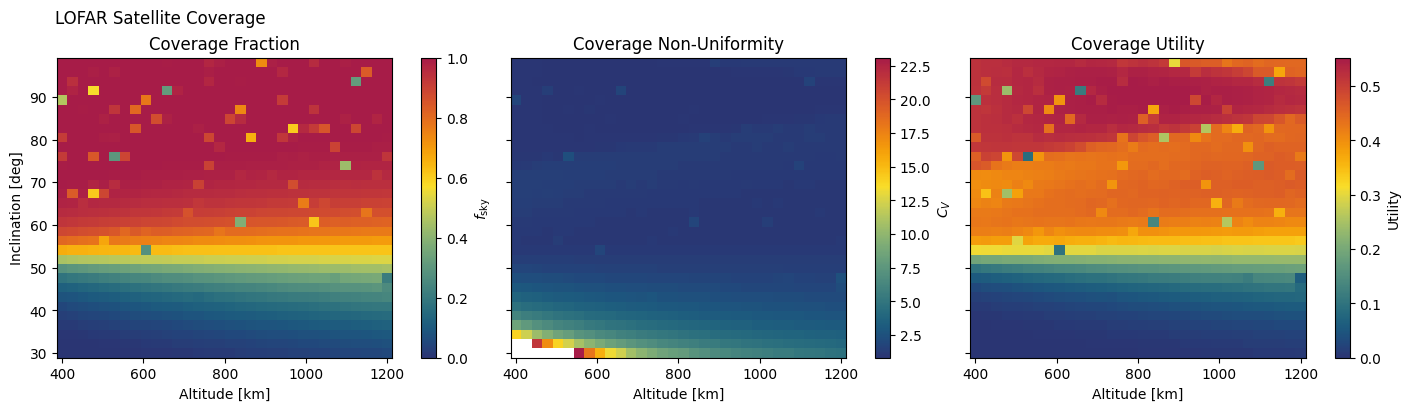

In [27]:
fig, axs = plt.subplots(
    ncols=3,
    figsize=(14, 4),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

im0 = axs[0].pcolormesh(
    altitudes,
    inclinations,
    fsky_grid_lofar,
    shading="auto",
    cmap=prd
)

cbar0 = fig.colorbar(im0, ax=axs[0])
cbar0.set_label(r"$f_\mathrm{sky}$")

axs[0].set_title("Coverage Fraction")
axs[0].set_xlabel("Altitude [km]")
axs[0].set_ylabel("Inclination [deg]")


im1 = axs[1].pcolormesh(
    altitudes,
    inclinations,
    cv_grid_lofar,
    shading="auto",
    cmap=prd
)

cbar1 = fig.colorbar(im1, ax=axs[1])
cbar1.set_label(r"$C_V$")

axs[1].set_title("Coverage Non-Uniformity")
axs[1].set_xlabel("Altitude [km]")


im2 = axs[2].pcolormesh(
    altitudes,
    inclinations,
    utility_grid_lofar,
    shading="auto",
    cmap=prd
)

cbar2 = fig.colorbar(im2, ax=axs[2])
cbar2.set_label("Utility")

axs[2].set_title("Coverage Utility")
axs[2].set_xlabel("Altitude [km]")

fig.suptitle("LOFAR Satellite Coverage", x=0.11)

plt.show()